# Research Notebook
## Reamonn Franky James Leitzig
## Date: 02.03.2026

# 1: Experience
## Describe at least one research activity you worked on this week. 

- Finishing the galaxy cut list

- Run a MCMC Code for testing it


## Motivation:

- It's necessary to have good data for analysis with MCMC and the jeans model. Bad data with their errors are not good for the analysis, their errors can disturb other good results. Therefore, we cut out the bad data with different cuts.

- MCMC is our main tool for analysis. In this case, the MCMC code by someone else is tested to see how good it runs. 

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

- Writing the finished Galaxy Cut and creating a list with all passing galaxies

"""
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
from readData import *


galaxies_with_cuts = []

path = os.getcwd() + '/data/fit_data/'
filename_M_b = path + "M_b_comparison.csv"
filename_hern_fits = path + "hern_fits.csv"

hern_data = pd.read_csv(filename_hern_fits)
M_b_data = pd.read_csv(filename_M_b)

ChiSq_data = hern_data['ChiSq']

lowest_likelyhood = np.percentile(ChiSq_data, 20)
print(lowest_likelyhood)


galaxy_ids = get_galaxy_ids()



for galaxy_id in galaxy_ids:

    df, _, _ = get_rc_data(galaxy_id)

    if len(df) < 8:
        cut_1_datapoints = "fail"
    else:
        cut_1_datapoints = "pass"

    if 'Vbul' in df.columns and (df['Vbul'] > 0).any():
        cut_2_bulge = "fail"
    else:
        cut_2_bulge = "pass"

    sub_likelyhood = hern_data[hern_data["GalaxyID"] == galaxy_id]
    sub_likelyhood_chisq = sub_likelyhood["ChiSq"].values[0]
    
    if sub_likelyhood_chisq > lowest_likelyhood:
        cut_3_likelyhood = "pass"
    else: 
        cut_3_likelyhood = "fail"
        
    sub_M_b_data = M_b_data[M_b_data["GalaxyID"]== galaxy_id]
    difference_M_b = np.abs(sub_M_b_data['log_M_b_fit'].values[0] - sub_M_b_data['log_M_b'].values[0])
    
    if difference_M_b > 0.5:
        cut_4_dex = "fail"
    else:
        cut_4_dex = "pass"
    
    galaxies_with_cuts.append(
        (galaxy_id, cut_1_datapoints, cut_2_bulge, cut_3_likelyhood, cut_4_dex)
    )
    
results_df = pd.DataFrame(
    galaxies_with_cuts,
    columns=["galaxy_id", "Datapoint_Cut", "Bulge_Cut", "Likelyhood_Cut", "Dex_Cut"])

results_df.to_csv("Galaxy_Cuts_Results.csv", index=False)"""

- Cut 1 throws out all galaxies under 8 datapoints
- Cut 2 throws out all galaxies with a bulge value [1]
- Cut 3 throws the galaxies with the worst 20% likelyhood (in this case Chi^2) out [2]
- Cut 4 throws all galaxies with a dex over 0.5 out [3]

- All remaining galaxies are:   
"""galaxy_id
0    NGC4559
1    NGC5055
2    NGC3741
3    NGC1705
4    NGC4100
5    NGC5907
6    NGC4088
7    NGC6503
8    NGC0801
9    NGC3992
10  UGC12506
11  UGC09037
12  UGC05721
13   NGC2903
14   NGC1003
15   NGC0289
16   NGC6015
17  UGC05986
18   NGC0100
19   NGC3769
20   NGC5585
21   NGC1090
22   NGC2403
23   NGC2998
24  UGC07603
25   NGC3726
26    D631-7
27    F571-8
28  UGC08490
29   NGC3893
30   NGC4214
31   NGC3521
32   NGC3198
33   NGC5371
34  UGC08550
35   NGC2915"" 

- Mind, that the first galaxy has a zero instead of a one. 
- Without the dex cut, 98 galaxies are remaining. 

- The following MCMC code was written by Altan Günes [4]. I just ran it for the galaxy KK98-251 two times. 

"""
def log_prob(parameter, df, dist):
    M200 = parameter[0]
    if not (1e8 < M200 < 1e20): return -np.inf
    try :
        c = c_MCR(M200)
        profile = jeans.squashed(dist, M200, c)
        if profiles is None: return -np.inf
        v_model = profile.V(df['Rad'], Lmax =0)
        if not np.all(np.isfinite(v_model)): return -np.inf
        chi2 = np.sum(((df['Vobs'] - v_model) / df['errV'])**2)
        return -0.5 * chi2
    except:
        return -np.inf
    
if __name__ == '__main__':
    df, units_info, dist = get_data(filename)
    
    print("Performance test...")
    t_start = time.time()
    test_p = jeans.squashed(dist, 1e11, c_MCR(1e11))
    _ = test_p.V(df['Rad'], Lmax=0)
    t_single = time.time() - t_start
    print(f"Time for model: {t_single:.4f}s")
    
    ndim, nwalkers = 1, 8 
    n_steps = 500 # originally 500, I take 50
    start_val = 8.0000e10
    p0 = np.array([start_val]) * (1 + 1e-3 * np.random.randn(nwalkers, ndim))
    
    print (f"Duration (without parallel processing): {(t_single * n_steps * nwalkers / 60):.2f} Minutes")
    
    with Pool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(df, dist), pool=pool)
        print("Start parallel mcmc...")
        sampler.run_mcmc(p0, n_steps, progress =True)
        
    samples = sampler.get_chain(discard=100, flat=True)
    mbereich = np.percentile(samples, 50)
    print(f"Best M200: {mbereich:.4e}")
    """
    
- The result is following:
"""Performance test...
Time for model: 1.3351s
Duration (without parallel processing): 89.01 Minutes
Start parallel mcmc...
  0%|          | 0/500 [00:00<?, ?it/s]/home/ani/SPARC/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 500/500 [32:34<00:00,  3.91s/it]
Best M200: 8.0010e+10
"""

- The code run two times. 
- Result for nwalkers=8, n_steps = 500; Best M200: 8.0010e+10
- Results for nwalkers=4, n_steps = 500; Best M200: 7.9976e+10

- I tested it with a jeans model[5]:

"""
M200 = 7.9976e+10 
def c_MCR(M200):
    a, b = 0.905, -0.101
    h = 0.7
    c = 10**(a + b*np.log10(h*M200/1e12))
    
    return c

r1 = 22 
Phi_b = None 

profile = jeans.squashed(r1, M200, c, Phi_b=Phi_b, verbose=True)

plt.figure(figsize=(6,4))
plt.errorbar(df['Rad'], df['Vobs'], yerr=df['errV'], fmt='o', label='Observed', color='black', markersize=5)
plt.plot(df['Rad'], profile.V(df['Rad'], Lmax=0), label='Jeans Model', color='C0')


plt.xlabel(f"Radius ({units.at[0, 'Rad']})")
plt.ylabel(f"Velocity ({units.at[0, 'Vobs']})")
plt.title(f"Rotation Curve for KK98-251 (Distance: {dist} Mpc)")
plt.legend()
plt.grid()
plt.show()
""" 

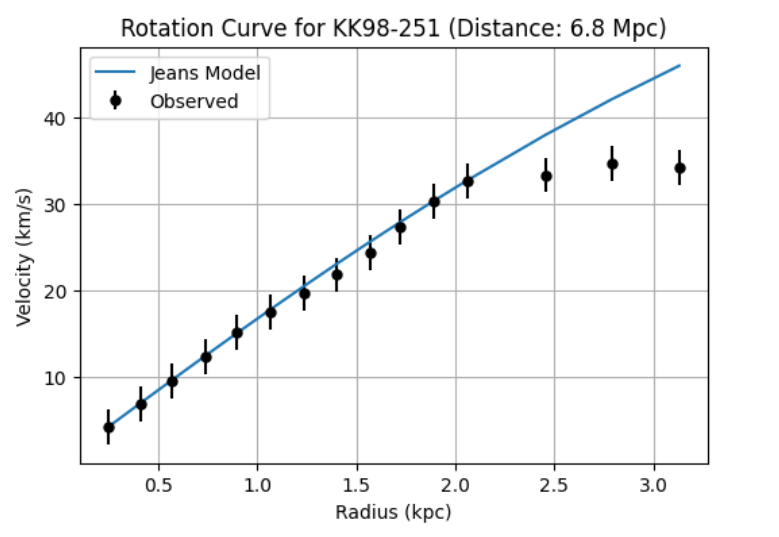

- The value for r1 is 22 in kpc and for M200 is it 7.9976e+10 in sun masses.

# 3: So what? (What does it mean?)
## Describe your results

- With all cuts, 36 Galaxies are remaining for further analysis. The fourth cut, the 0.5 dex cut, cuts of a lot of galaxies stritly out. The V_vir / V_max >= 1 is not there as in Zixiang Jia et al. (2026)[6] and there are less than the 68 Galaxies as on the paper. This shows, that the 0.5 dex cut is very strict and cuts more galaxies out, than necessary. This can be good or bad. Its good for more quality in data but it can also be bad for missing quantity.

- The MCMC Code could give a good M200 value for the galaxy, but the jeans model is still very linear. The MCMC is only one dimensional, it doesn't give a best value for r1. KK98-251 is also not a part of the remaining 36 galaxies. It's maybe for this galaxy important to have a good Phi_b component, which fits good. 

# 4. Now what? (What's next?)
## Plan for the next week

- One plan for the next week is to improve the galaxy cut, if necessary.

- Anotehr plan is to contribute and write on the new improved MCMC script, which is better as the one that was used here, and helping the EXPLORE group. 



# 5. Bibliography

Your references here

In [ ]:
# [1]: Part of the bulge code is by Altan Günes, the rest is from me

# [2]: Percentile: https://numpy.org/doc/stable/reference/generated/numpy.percentile.html

# [3]: Part of the bulge code is by Adam Smith Orlik, the rest is from me

# [4]: The whole code is by ALtan Günes

# [5]: "Cold dark matter haloes in the Planck era: evolution of structural parameters for Einasto and NFW profiles" by Aaron A. Dutton and Andrea V. Macciò
# Submitted on 29.04.2014
# https://arxiv.org/abs/1402.7073
# for the c and M200 relation

# [6]: "An Enhanced Isothermal Jeans Approach to Constraining Dark Matter Self-Interactions from Galactic Kinematics" by Zixiang Jia1, Fangzhou Jiang, Shubo Li, Ran Li, Jing Wang and Ling Zhu
# Submitted on 23.01.2026
# https://arxiv.org/abs/2601.17118





